<a href="https://www.kaggle.com/code/immadirohan/milestone-4?scriptVersionId=279807711" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**MileStone - 4**

**Week - 7 : Alert Generation and Logging**

Loading dataset...
Dataset shape: (692703, 79)

Performing correlation analysis...


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


Selected Features: ['Idle Max', 'Fwd IAT Max', 'Flow IAT Max', 'Fwd IAT Std', 'Idle Mean', 'Idle Min', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Flow IAT Std', 'Bwd Packet Length Std', 'Bwd Packet Length Max', 'Packet Length Std', 'Max Packet Length', 'Packet Length Mean', 'Average Packet Size', 'Packet Length Variance', 'Fwd IAT Total', 'Flow Duration', 'Fwd IAT Mean', 'Bwd Packet Length Min', 'Flow IAT Mean', 'Min Packet Length', 'ACK Flag Count', 'FIN Flag Count']

Preprocessing...

Training Random Forest model...

=== RANDOM FOREST RESULTS ===
Training Accuracy: 0.9884
Testing Accuracy: 0.9869
Precision: 0.9872
Recall: 0.9869
F1 Score: 0.9869


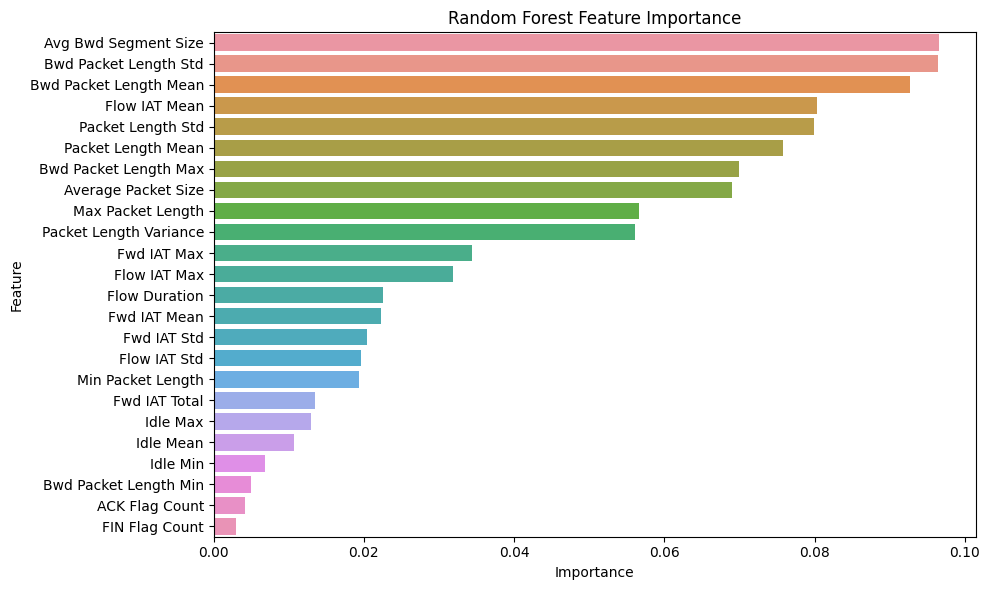


Model saved successfully:
- random_forest_model.pkl
- scaler.pkl
- selected_features.pkl

Pipeline completed successfully!


In [6]:
# ==============================================================
# NETWORK INTRUSION DETECTION SYSTEM (Random Forest Only)
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

# ==============================================================
# Step 1: Load Dataset
# ==============================================================

print("Loading dataset...")

file_path = '/kaggle/input/wednesday-workinghours-pcap-iscx/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path, low_memory=False)

df.columns = df.columns.str.strip()
print("Dataset shape:", df.shape)

# Encode Labels
if "Label" in df.columns:
    le = LabelEncoder()
    df["Label"] = le.fit_transform(df["Label"])
else:
    raise Exception("ERROR: 'Label' column not found!")

# ==============================================================
# Step 2: Correlation-Based Feature Selection
# ==============================================================

print("\nPerforming correlation analysis...")

numeric_df = df.select_dtypes(include=['int64', 'float64', 'float32']).copy()

corr = numeric_df.corr()["Label"].abs().sort_values(ascending=False)
corr = corr.drop(labels=["Label"], errors='ignore')

important_features = corr[corr > 0.3].index.tolist()

if len(important_features) == 0:
    important_features = corr.head(10).index.tolist()

print("Selected Features:", important_features)

df_filtered = df[important_features + ["Label"]]

# ==============================================================
# Step 3: Preprocessing (Imputation + Scaling)
# ==============================================================

print("\nPreprocessing...")

X = df_filtered.drop(columns=["Label"])
y = df_filtered["Label"]

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================
# Step 4: Random Forest Training
# ==============================================================

print("\nTraining Random Forest model...")

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ==============================================================
# Step 5: Evaluation
# ==============================================================

y_pred = rf.predict(X_test)

print("\n=== RANDOM FOREST RESULTS ===")
print(f"Training Accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# ==============================================================
# Step 6: Feature Importance Plot
# ==============================================================

importance_df = pd.DataFrame({
    "Feature": important_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# ==============================================================
# Step 7: Save Model + Scaler
# ==============================================================

joblib.dump(rf, "/kaggle/working/random_forest_model.pkl")
joblib.dump(scaler, "/kaggle/working/scaler.pkl")
joblib.dump(important_features, "/kaggle/working/selected_features.pkl")

print("\nModel saved successfully:")
print("- random_forest_model.pkl")
print("- scaler.pkl")
print("- selected_features.pkl")

print("\nPipeline completed successfully!")


In [23]:
import os

print(os.listdir("/kaggle/working"))
print(os.listdir("/kaggle/input"))


['selected_features.pkl', '.virtual_documents', 'random_forest_model.pkl', 'scaler.pkl']
['wednesday-workinghours-pcap-iscx']


In [24]:
import pandas as pd
import joblib

file_path = '/kaggle/input/wednesday-workinghours-pcap-iscx/Wednesday-workingHours.pcap_ISCX.csv'

df = pd.read_csv(file_path, low_memory=False)
df.columns = df.columns.str.strip()

selected_features = joblib.load("/kaggle/working/selected_features.pkl")

df_selected = df[selected_features + ['Label']]

df_selected.to_csv("/kaggle/working/top10_features_dataset.csv", index=False)

print("File created:", "/kaggle/working/top10_features_dataset.csv")
df_selected.head()


File created: /kaggle/working/top10_features_dataset.csv


,Idle Max,Fwd IAT Max,Flow IAT Max,Fwd IAT Std,Idle Mean,Idle Min,Bwd Packet Length Mean,Avg Bwd Segment Size,Flow IAT Std,Bwd Packet Length Std,...,Packet Length Variance,Fwd IAT Total,Flow Duration,Fwd IAT Mean,Bwd Packet Length Min,Flow IAT Mean,Min Packet Length,ACK Flag Count,FIN Flag Count,Label
0,0,0,38308,0.000000,0.0,0,6.000000,6.000000,0.000000,0.000000,...,0.000000,0,38308,0.000000,6,38308.000000,6,1,0,BENIGN
1,0,109,73,38.942836,0.0,0,65.200000,65.200000,25.510409,89.278777,...,3195.595588,479,479,47.900000,0,31.933333,0,0,0,BENIGN
2,0,915,810,298.746130,0.0,0,525.000000,525.000000,204.960972,813.326503,...,451250.132400,1095,1095,121.666667,0,73.000000,0,0,0,BENIGN
3,0,13391,13391,3322.417812,0.0,0,555.000000,555.000000,2519.931377,977.480342,...,496537.374700,15206,15206,950.375000,0,543.071429,0,0,0,BENIGN
4,0,910,794,313.850738,0.0,0,525.333333,525.333333,207.000929,813.842901,...,496440.116700,1092,1092,136.500000,0,78.000000,0,0,0,BENIGN


In [27]:
df = pd.read_csv("/kaggle/working/top10_features_dataset.csv")
df.shape


(692703, 25)

In [25]:
# Load top-10-features dataset
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Shape of the test sample : ", X_test.shape)

Feature matrix shape: (692703, 78)
Target vector shape: (692703, 1)
Shape of the test sample :  (138541, 78)


In [29]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/kaggle/working/top10_features_dataset.csv")

X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = joblib.load("/kaggle/working/random_forest_model.pkl")

print("Random Forest model loaded successfully!")



Random Forest model loaded successfully!


**Step 2: Generate Alerts and Logging**

In [30]:
import time
import numpy as np

print("\nReal-Time Prediction Simulation Started...\n")

num_samples = 10

for idx in range(num_samples):
    current_sample = X_test_scaled[idx].reshape(1, -1)
    pred = rf_model.predict(current_sample)[0]

    status = "Intrusion Detected" if pred == 1 else "Normal Activity"
    print(f"Sample {idx + 1}: {status}")

    time.sleep(1)



Real-Time Prediction Simulation Started...

Sample 1: Normal Activity
Sample 2: Normal Activity
Sample 3: Normal Activity
Sample 4: Normal Activity
Sample 5: Normal Activity
Sample 6: Normal Activity
Sample 7: Normal Activity
Sample 8: Normal Activity
Sample 9: Normal Activity
Sample 10: Normal Activity


In [31]:
from datetime import datetime
import pandas as pd
import numpy as np

y_pred = rf_model.predict(X_test_scaled)

y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

alert_log = pd.DataFrame({
    "Timestamp": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")] * len(y_pred_flat),
    "Actual_Label": y_test_flat,
    "Predicted_Label": y_pred_flat
})

alert_log["Alert_Message"] = alert_log["Predicted_Label"].apply(
    lambda x: "Intrusion Detected" if x == 1 else "Normal Activity"
)

alert_log.head()


,Timestamp,Actual_Label,Predicted_Label,Alert_Message
0,2025-11-19 06:03:16,BENIGN,0,Normal Activity
1,2025-11-19 06:03:16,BENIGN,0,Normal Activity
2,2025-11-19 06:03:16,BENIGN,0,Normal Activity
3,2025-11-19 06:03:16,BENIGN,0,Normal Activity
4,2025-11-19 06:03:16,BENIGN,0,Normal Activity


In [32]:
alert_counts = alert_log["Alert_Message"].value_counts()

print("Detection Summary:")
print(alert_counts)

print("\nPercentage Breakdown:")
print((alert_counts / len(alert_log) * 100).round(2))


Detection Summary:
Alert_Message
Normal Activity       136497
Intrusion Detected      2044
Name: count, dtype: int64

Percentage Breakdown:
Alert_Message
Normal Activity       98.52
Intrusion Detected     1.48
Name: count, dtype: float64


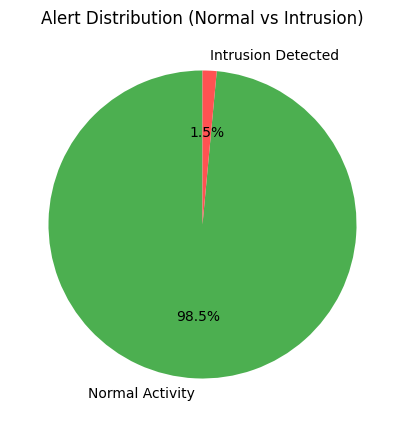

In [33]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

alert_counts = alert_log["Alert_Message"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    alert_counts.values,
    labels=alert_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#FF5252']
)
plt.title("Alert Distribution (Normal vs Intrusion)")
plt.show()


*The Random Forest model predicts whether network traffic is normal or an intrusion.

An alert log is created with timestamp, actual label, predicted label, and a simple message.

The message clearly shows if the traffic is safe or suspicious.

The full alert log is saved in alerts_log.csv for complete records.

Only intrusion cases are saved separately in intrusion_alerts.csv.

This helps admins quickly check dangerous activities.

The process works like a real intrusion detection system.*

**Step 3: Save Alerts**

In [34]:
# Save alerts to a CSV file
alert_log.to_csv("alerts_log.csv", index=False)
print(" Alerts log saved successfully as 'alerts_log.csv'")

 Alerts log saved successfully as 'alerts_log.csv'
